In [1]:
import cmocean
import cartopy.crs as ccrs
import seaborn as sns
import matplotlib.pyplot as plt
import xarray as xr
from matplotlib import cm
import numpy as np

/home/maltem/.local/lib/python3.10/site-packages/pandas/core/arrays/masked.py:62: UserWarning: Pandas requires version '1.3.4' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


In [9]:
mpath = "/lustre/storeB/project/nwp/SALIENSEAS/SvalMIZ2024/models/"

In [45]:
models = [ 'DWD-ICON', 'ECMWF-IFS','MF-ARPEGE','ECCC-HRDPSN','MET-AROMEArctic',    'MF-AROME']
   
T2Mvarn= [ '2t',       'T2M'      ,'T_2M'     ,'Tair'       ,'air_temperature_2m', 'T_2M']
Hicvarn= [ 'icetk'   , 'var98'    ,'H_ICE'    ,''           ,'SFX_ICE_THK', 'H_ICE']

In [46]:
T2Mens = np.zeros((6,54,949,739))

for m in range(len(models)):
  
    ifile= models[m]+'_04042025-30042025_AAgrid_00L.nc'
    print (ifile)
    fc = xr.open_dataset(mpath+'AnalysisOfFields/'+ifile)
    
    if models[m]=='ECCC-HRDPSN':    
        print(np.shape(np.squeeze(fc[T2Mvarn[m]][:,1,:,:])))
        T2Mens[m,:,:,:]=np.squeeze(fc[T2Mvarn[m]][:,1,:,:]+273.15)
    else:
        print(np.shape(np.squeeze(fc[T2Mvarn[m]])))
        T2Mens[m,:,:,:]=np.squeeze(fc[T2Mvarn[m]])
    fc.close()
    
HICEens = np.zeros((5,54,949,739))
i=-1
for m in [0,1,2,4,5]:
    i=i+1
    ifile= models[m]+'_04042025-30042025_AAgrid_00L.nc'
    print (ifile)
    fc = xr.open_dataset(mpath+'AnalysisOfFields/'+ifile)
    
    if models[m]=='ECCC-HRDPSN':    
        print(np.shape(np.squeeze(fc[T2Mvarn[m]][:,1,:,:])))
        #T2Mens[m,:,:,:]=np.squeeze(fc[T2Mvarn[m]][:,1,:,:]+273.15)
    else:
        print(np.shape(np.squeeze(fc[Hicvarn[m]])))
        HICEens[i,:,:,:]=np.squeeze(fc[Hicvarn[m]])
    fc.close()
    
    

DWD-ICON_04042025-30042025_AAgrid_00L.nc
(54, 949, 739)
ECMWF-IFS_04042025-30042025_AAgrid_00L.nc
(54, 949, 739)
MF-ARPEGE_04042025-30042025_AAgrid_00L.nc
(54, 949, 739)
ECCC-HRDPSN_04042025-30042025_AAgrid_00L.nc
(54, 949, 739)
MET-AROMEArctic_04042025-30042025_AAgrid_00L.nc
(54, 949, 739)
MF-AROME_04042025-30042025_AAgrid_00L.nc
(54, 949, 739)
DWD-ICON_04042025-30042025_AAgrid_00L.nc
(54, 949, 739)
ECMWF-IFS_04042025-30042025_AAgrid_00L.nc
(54, 949, 739)
MF-ARPEGE_04042025-30042025_AAgrid_00L.nc
(54, 949, 739)
MET-AROMEArctic_04042025-30042025_AAgrid_00L.nc
(54, 949, 739)
MF-AROME_04042025-30042025_AAgrid_00L.nc
(54, 949, 739)


In [41]:
spread_T2M = np.std(T2Mens, axis=0).mean(axis=0)  # shape: (x, y)

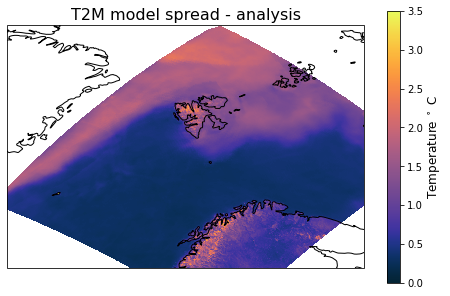

In [42]:
fc = xr.open_dataset(mpath+'AnalysisOfFields/'+ifile)

plot_proj = ccrs.Orthographic(14,25)
k=0;l=0

fig, ax = plt.subplots(figsize=(8, 5),nrows=1,ncols=1,
                        subplot_kw={'projection': plot_proj})

ax.coastlines(resolution='50m')
ax.set_extent([-10, 38, 65, 88], crs=ccrs.PlateCarree())

contour1 = ax.pcolormesh(fc.longitude, fc.latitude, spread_T2M, transform=ccrs.PlateCarree(), cmap=cmocean.cm.thermal, vmax=3.5, vmin=0,alpha=1)
    
ax.set_title('T2M model spread - analysis', fontsize=16)
fc.close()
plt.subplots_adjust(wspace=0.1, hspace=0.1)        
cbar = fig.colorbar(contour1, ax=ax,location = 'right')
#plt.subplots_adjust(wspace=0.1, hspace=0.1)
#plt.tight_layout() 
cbar.set_label('Temperature $^\circ$ C', fontsize=12)
plt.savefig('ensemble_spread_T2M_0h.png', dpi=300, bbox_inches='tight')  

In [47]:
spread_HICE = np.std(HICEens, axis=0).mean(axis=0)  # shape: (x, y)

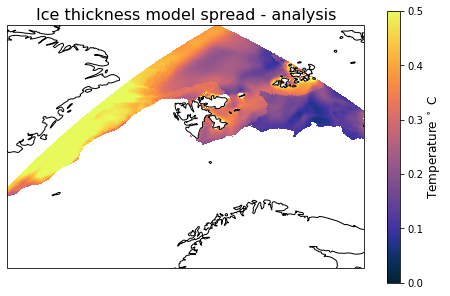

In [51]:
fc = xr.open_dataset(mpath+'AnalysisOfFields/'+ifile)

plot_proj = ccrs.Orthographic(14,25)
k=0;l=0

fig, ax = plt.subplots(figsize=(8, 5),nrows=1,ncols=1,
                        subplot_kw={'projection': plot_proj})

ax.coastlines(resolution='50m')
ax.set_extent([-10, 38, 65, 88], crs=ccrs.PlateCarree())

contour1 = ax.pcolormesh(fc.longitude, fc.latitude, spread_HICE, transform=ccrs.PlateCarree(), cmap=cmocean.cm.thermal, vmax=0.5, vmin=0,alpha=1)
    
ax.set_title('Ice thickness model spread - analysis', fontsize=16)
fc.close()
plt.subplots_adjust(wspace=0.1, hspace=0.1)        
cbar = fig.colorbar(contour1, ax=ax,location = 'right')
#plt.subplots_adjust(wspace=0.1, hspace=0.1)
#plt.tight_layout() 
cbar.set_label('Temperature $^\circ$ C', fontsize=12)
plt.savefig('ensemble_spread_HICE_0h.png', dpi=300, bbox_inches='tight')  